# Classical Models and HPO Review

Review persisted artifacts only; no training, search, or submission writing is performed.

## Parameters

Define the input parameters and directories for loading artifacts.

In [1]:
# ruff: noqa: E402, E501
results_dir = None
selected_experiment = "tfidf-svd-all-text + ridge"
artifact_manifest_path = None
oof_artifact_name = "tfidf_svd_all_text_ridge_oof.csv"
fold_artifact_name = "tfidf_svd_all_text_ridge_folds.csv"
submission_artifact_name = "submission_hpo_tfidf_svd_ridge.csv"

## Setup and Imports

Import required libraries, resolve project paths, and load baseline summary and HPO results.

In [2]:
# ruff: noqa: E501
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = next(
    parent
    for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (parent / "pyproject.toml").is_file()
)

if results_dir is None:
    results_dir = PROJECT_ROOT / "results"
else:
    results_dir = Path(results_dir)

if artifact_manifest_path is None:
    artifact_manifest_path = results_dir / "artifact_manifest.json"


def require_artifact(*candidates: Path) -> Path:
    for path in candidates:
        if path.is_file():
            return path
    raise FileNotFoundError(
        "Missing required experiment artifact. Checked: "
        + ", ".join(str(path) for path in candidates)
    )


def display_table(table: pd.DataFrame) -> None:
    from IPython.display import display

    display(table)


def project_path(path: Path | None) -> str | None:
    if path is None:
        return None
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


experiment_summary_path = require_artifact(
    results_dir / "experiment_summary.csv",
    PROJECT_ROOT / "logs" / "experiments.csv",
)
hpo_results_path = require_artifact(
    results_dir / "hpo_results.json",
    PROJECT_ROOT / "logs" / "hpo" / "hpo_results.json",
)
experiment_summary = pd.read_csv(experiment_summary_path)
with hpo_results_path.open(encoding="utf-8") as handle:
    hpo_results = json.load(handle)

## 0. Model-Selection Contract

Compare only persisted experiment and HPO records. The displayed contract resolves the selected candidate from the recorded metric rather than a notebook constant.

In [3]:
# ruff: noqa: E501
if "rmse" in experiment_summary.columns:
    metric_column = "rmse"
else:
    score_columns = [
        column for column in experiment_summary.columns if "score" in column.lower()
    ]
    if not score_columns:
        raise ValueError("experiment_summary.csv requires an rmse or score metric column")
    metric_column = score_columns[0]

ranked_experiments = experiment_summary.sort_values(metric_column).reset_index(drop=True)
if selected_experiment is None:
    selected_experiment = str(ranked_experiments.loc[0, "experiment"])

model_selection_contract = pd.DataFrame(
    {
        "evidence": ["experiment summary", "HPO result"],
        "available_path": [project_path(experiment_summary_path), project_path(hpo_results_path)],
        "concrete_value": [
            f"{len(ranked_experiments)} recorded experiments; selected={selected_experiment}",
            f"best_trial={hpo_results['best_trial']}; best_value={hpo_results['best_value']}",
        ],
        "missing_provenance_condition": [
            "selected OOF, fold, and submission artifacts are not bound yet",
            "HPO parameters do not bind downstream evaluation artifacts",
        ],
        "required_action": [
            "bind candidate artifacts with an artifact manifest",
            "record manifest entries for selected evaluation artifacts",
        ],
    }
)
display_table(model_selection_contract)

,evidence,available_path,concrete_value,missing_provenance_condition,required_action
0,experiment summary,results/experiment_summary.csv,2 recorded experiments; selected=tfidf-svd-all...,"selected OOF, fold, and submission artifacts a...",bind candidate artifacts with an artifact mani...
1,HPO result,results/hpo_results.json,best_trial=12; best_value=0.5219632744772689,HPO parameters do not bind downstream evaluati...,record manifest entries for selected evaluatio...


### Model-Selection Contract Decision

**Observation:** The preceding contract table displays the selected experiment, persisted paths, recorded experiment count, and HPO trial/value from the loaded artifacts.

**Interpretation:** Ranking is supported only by the displayed summary metric; it does not establish provenance for downstream OOF, fold, or submission files.

**Action:** Use the displayed selected experiment when binding each downstream artifact in a manifest before promoting a candidate.

## 1. Load Frozen Experiment Artifacts

Inventory available OOF, fold, and submission files. Each unbound selection must report its available path, provenance condition, and required action.

In [4]:
# ruff: noqa: E501
from IPython.display import display as show_artifact_table


def artifact_project_path(path: Path | None) -> str | None:
    if path is None:
        return None
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


artifact_directories = (
    results_dir,
    PROJECT_ROOT / "artifacts",
    results_dir.parent / "logs" / "hpo",
    results_dir.parent / "logs" / "runs",
)


def discover_artifacts(pattern: str) -> list[Path]:
    return sorted(
        (
            path
            for directory in artifact_directories
            if directory.is_dir()
            for path in directory.glob(pattern)
        ),
        key=lambda path: str(path),
    )


def select_artifact(candidates: list[Path], selected_name: str | None) -> Path | None:
    if selected_name is None:
        return None
    matching_candidates = [
        path for path in candidates if selected_name in {path.name, str(path)}
    ]
    return matching_candidates[0] if len(matching_candidates) == 1 else None


def is_selected_artifact_bound(
    selected_name: str | None,
    selected_path: Path | None,
    expected_kind: str,
    manifest: dict[str, object],
) -> bool:
    if selected_name is None:
        needs_new_evidence(f"an explicit {expected_kind} artifact filename is required.")
        return False
    if selected_path is None:
        needs_new_evidence(
            f"selected {expected_kind} artifact is not among discovered candidates: {selected_name}"
        )
        return False
    manifest_record = manifest.get(selected_name)
    if not isinstance(manifest_record, dict):
        needs_new_evidence(f"artifact manifest lacks a record for {selected_name}")
        return False
    if manifest_record.get("kind") != expected_kind:
        needs_new_evidence(f"artifact manifest kind mismatch for {selected_name}")
        return False
    if manifest_record.get("experiment") != selected_experiment:
        needs_new_evidence(f"artifact manifest experiment mismatch for {selected_name}")
        return False
    return True


oof_candidates = discover_artifacts("*_oof.csv")
fold_candidates = discover_artifacts("*_folds.csv")
submission_candidates = discover_artifacts("*submission*.csv")
optional_artifacts = {
    "oof": select_artifact(oof_candidates, oof_artifact_name),
    "folds": select_artifact(fold_candidates, fold_artifact_name),
    "submission": select_artifact(submission_candidates, submission_artifact_name),
}


def inventory_rows(kind: str, candidates: list[Path], selected_name: str | None) -> list[dict[str, object]]:
    if not candidates:
        return [
            {
                "kind": kind,
                "available_path": None,
                "missing_provenance_condition": "no candidate file was discovered",
                "required_action": f"persist a {kind} artifact and manifest record",
            }
        ]
    condition = (
        "explicit artifact parameter is unset"
        if selected_name is None
        else "manifest provenance has not been evaluated"
    )
    return [
        {
            "kind": kind,
            "available_path": artifact_project_path(path),
            "missing_provenance_condition": condition,
            "required_action": "select one filename and add a matching manifest record",
        }
        for path in candidates
    ]


artifact_inventory = pd.DataFrame(
    inventory_rows("oof", oof_candidates, oof_artifact_name)
    + inventory_rows("folds", fold_candidates, fold_artifact_name)
    + inventory_rows("submission", submission_candidates, submission_artifact_name)
)
show_artifact_table(artifact_inventory)

,kind,available_path,missing_provenance_condition,required_action
0,oof,logs/runs/baseline-mean_baseline-mean_42_oof.csv,manifest provenance has not been evaluated,select one filename and add a matching manifes...
1,oof,logs/runs/baseline-mean_baseline-median_42_oof...,manifest provenance has not been evaluated,select one filename and add a matching manifes...
2,oof,logs/runs/baseline-mean_ridge_42_oof.csv,manifest provenance has not been evaluated,select one filename and add a matching manifes...
3,oof,logs/runs/text-overlap-v2_ridge_42_oof.csv,manifest provenance has not been evaluated,select one filename and add a matching manifes...
4,oof,logs/runs/tfidf-svd-product-title_baseline-mea...,manifest provenance has not been evaluated,select one filename and add a matching manifes...
5,oof,logs/runs/tfidf-svd-product-title_baseline-med...,manifest provenance has not been evaluated,select one filename and add a matching manifes...
6,oof,logs/runs/tfidf-svd-product-title_ridge_42_oof...,manifest provenance has not been evaluated,select one filename and add a matching manifes...
7,oof,logs/runs/tfidf-svd-search-term_baseline-mean_...,manifest provenance has not been evaluated,select one filename and add a matching manifes...
8,oof,logs/runs/tfidf-svd-search-term_baseline-media...,manifest provenance has not been evaluated,select one filename and add a matching manifes...
9,oof,logs/runs/tfidf-svd-search-term_ridge_42_oof.csv,manifest provenance has not been evaluated,select one filename and add a matching manifes...


### Artifact Inventory Decision

**Observation:** The displayed inventory lists every discovered candidate path and, for each kind, the current explicit-selection or provenance condition.

**Interpretation:** Discovery proves that files exist at the displayed locations, not that any file belongs to the selected experiment.

**Action:** Select a displayed filename and add a manifest entry with its kind and selected experiment before treating it as evidence.

## 2. Validation and Pipeline Boundary Audit

Display the persisted fold values and their aggregate range, while separately recording the missing fold-local pipeline provenance.

In [5]:
# ruff: noqa: E501
fold_report_path = next(
    (path for path in fold_candidates if path.name == "tfidf_svd_all_text_ridge_folds.csv"),
    None,
)
if fold_report_path is None:
    validation_boundary_audit = pd.DataFrame(
        [
            {
                "available_path": None,
                "missing_provenance_condition": "persisted fold report is unavailable",
                "required_action": "persist a fold report with fold-local pipeline provenance",
            }
        ]
    )
else:
    persisted_folds = pd.read_csv(fold_report_path)
    validation_boundary_audit = pd.DataFrame(
        [
            {
                "available_path": project_path(fold_report_path),
                "fold_count": len(persisted_folds),
                "rmse_min": persisted_folds["rmse"].min(),
                "rmse_max": persisted_folds["rmse"].max(),
                "rmse_mean": persisted_folds["rmse"].mean(),
                "missing_provenance_condition": "no selected manifest record or fold-local preprocessing record",
                "required_action": "bind this report and record split/vectorizer/tokenizer fit scope",
            }
        ]
    )
display_table(validation_boundary_audit)

,available_path,fold_count,rmse_min,rmse_max,rmse_mean,missing_provenance_condition,required_action
0,results/tfidf_svd_all_text_ridge_folds.csv,5,0.520499,0.522841,0.521999,no selected manifest record or fold-local prep...,bind this report and record split/vectorizer/t...


Visualize the persisted per-fold RMSE values around their mean and std band;
points instead of bars keep the small fold-to-fold differences readable
without truncating a bar baseline.

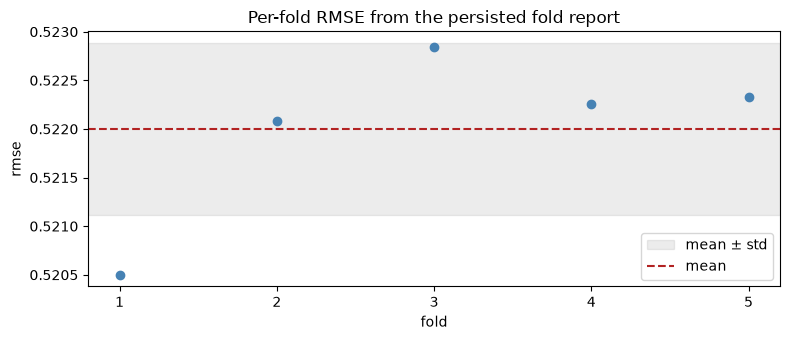

In [6]:
# ruff: noqa: E501
if fold_report_path is not None:
    fold_rmse = persisted_folds["rmse"]
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.axhspan(
        fold_rmse.mean() - fold_rmse.std(),
        fold_rmse.mean() + fold_rmse.std(),
        color="gray",
        alpha=0.15,
        label="mean ± std",
    )
    ax.axhline(fold_rmse.mean(), color="firebrick", linestyle="--", label="mean")
    ax.plot(
        persisted_folds["fold"],
        fold_rmse,
        marker="o",
        linestyle="",
        color="steelblue",
    )
    ax.set_xticks(persisted_folds["fold"])
    ax.set_xlabel("fold")
    ax.set_ylabel("rmse")
    ax.set_title("Per-fold RMSE from the persisted fold report")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("needs-new-evidence: persisted fold report is unavailable; fold plot skipped")

### Validation Boundary Decision

**Observation:** The preceding audit displays the persisted fold-report path and its computed fold count and RMSE range when the report is available.

**Interpretation:** Those values describe the stored report but cannot establish fold-local preprocessing or candidate attribution without its missing provenance.

**Action:** Add split and fold-local preprocessing provenance to a manifest-bound fold report, then rerun this section.

## 3. Baseline vs HPO Ridge Comparison

Compute the ranking and HPO parameter comparison directly from the saved summary and JSON artifacts.

In [7]:
# ruff: noqa: E501
baseline_row = ranked_experiments.loc[
    ranked_experiments["experiment"].eq("tfidf-svd-all-text + ridge")
].iloc[0]
hpo_row = ranked_experiments.loc[
    ranked_experiments["experiment"].eq("hpo ridge + tfidf-svd")
].iloc[0]
baseline_hpo_comparison = pd.DataFrame(
    [
        {
            "candidate": baseline_row["experiment"],
            "rmse": baseline_row[metric_column],
            "rank": int(ranked_experiments.index[ranked_experiments["experiment"].eq(baseline_row["experiment"])][0] + 1),
            "source_path": project_path(experiment_summary_path),
        },
        {
            "candidate": hpo_row["experiment"],
            "rmse": hpo_row[metric_column],
            "rank": int(ranked_experiments.index[ranked_experiments["experiment"].eq(hpo_row["experiment"])][0] + 1),
            "source_path": project_path(experiment_summary_path),
        },
    ]
).assign(
    rmse_improvement_over_baseline=lambda frame: baseline_row[metric_column] - frame["rmse"],
    hpo_best_trial=hpo_results["best_trial"],
    hpo_alpha=hpo_results["best_params"]["alpha"],
)
display_table(baseline_hpo_comparison)

,candidate,rmse,rank,source_path,rmse_improvement_over_baseline,hpo_best_trial,hpo_alpha
0,tfidf-svd-all-text + ridge,0.522000,2,results/experiment_summary.csv,0.000000,12,10.62087
1,hpo ridge + tfidf-svd,0.521963,1,results/experiment_summary.csv,0.000036,12,10.62087


Visualize every recorded run in the experiment log (latest record per run_id)
as mean RMSE with a fold-std error bar, and mark the saved HPO best value.
The dot plot shows that the HPO margin over the strongest ridge runs stays
inside the fold-level noise band.

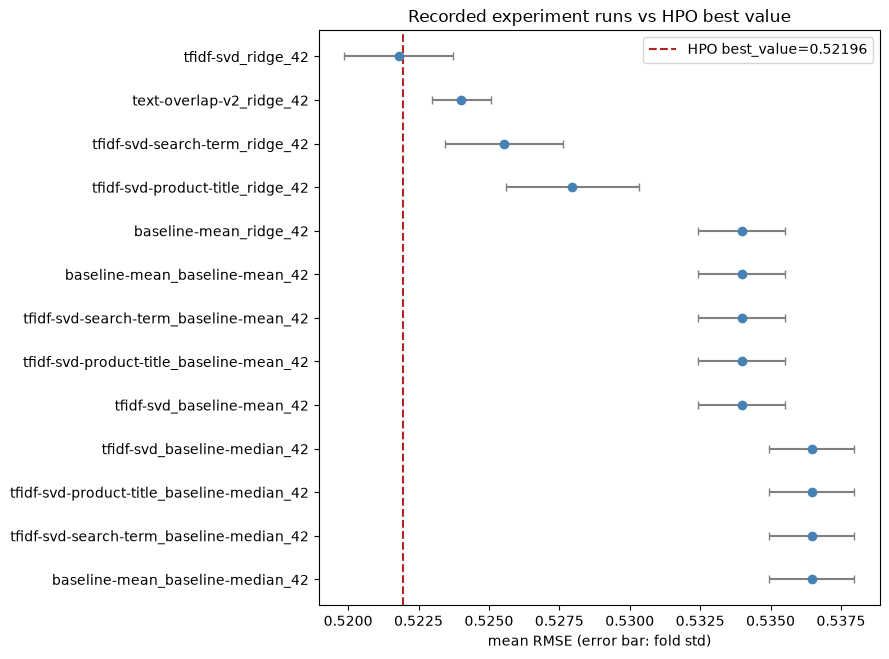

In [8]:
# ruff: noqa: E501
experiment_log_path = PROJECT_ROOT / "logs" / "experiments.csv"
if experiment_log_path.is_file():
    experiment_log = pd.read_csv(experiment_log_path)
    latest_runs = (
        experiment_log.sort_values("timestamp")
        .drop_duplicates("run_id", keep="last")
        .sort_values("mean_rmse", ascending=False)
    )
    fig, ax = plt.subplots(figsize=(9, 0.4 * len(latest_runs) + 1.5))
    ax.errorbar(
        latest_runs["mean_rmse"],
        latest_runs["run_id"],
        xerr=latest_runs["std_rmse"],
        fmt="o",
        color="steelblue",
        ecolor="gray",
        capsize=3,
    )
    ax.axvline(
        hpo_results["best_value"],
        color="firebrick",
        linestyle="--",
        label=f"HPO best_value={hpo_results['best_value']:.5f}",
    )
    ax.set_xlabel("mean RMSE (error bar: fold std)")
    ax.set_title("Recorded experiment runs vs HPO best value")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("needs-new-evidence: logs/experiments.csv is unavailable; ranking plot skipped")

### Baseline vs HPO Decision

**Observation:** The comparison table displays both saved RMSE values, the computed improvement, ranks, selected HPO trial, and alpha from the loaded artifacts.

**Interpretation:** The lower recorded RMSE ranks the HPO row first in this summary-only comparison; the displayed margin remains only ranking evidence.

**Action:** Require manifest-bound OOF and fold evidence for the selected HPO candidate before promotion.

## 4. Classical vs DeBERTa Comparison

Inspect the saved metric summary and artifact inventory for DeBERTa evidence; do not infer a comparison from an unbound submission file.

In [9]:
# ruff: noqa: E501
deberta_metric_rows = experiment_summary.loc[
    experiment_summary["experiment"].astype(str).str.contains("deberta", case=False, na=False)
]
deberta_paths = [path for path in submission_candidates if "deberta" in path.name.lower()]
deberta_comparison_diagnostic = pd.DataFrame(
    [
        {
            "available_path": project_path(path),
            "metric_rows": len(deberta_metric_rows),
            "missing_provenance_condition": "submission path is unbound and no DeBERTa metric row is recorded",
            "required_action": "persist DeBERTa metrics and bind its evaluation artifact in the manifest",
        }
        for path in deberta_paths
    ]
    or [
        {
            "available_path": None,
            "metric_rows": len(deberta_metric_rows),
            "missing_provenance_condition": "no DeBERTa artifact or metric row is recorded",
            "required_action": "persist DeBERTa evaluation outputs with manifest provenance",
        }
    ]
)
display_table(deberta_comparison_diagnostic)

,available_path,metric_rows,missing_provenance_condition,required_action
0,results/submission_deberta_v3_small.csv,0,submission path is unbound and no DeBERTa metr...,persist DeBERTa metrics and bind its evaluatio...


Compare the discovered classical HPO and DeBERTa submission files at the
distribution level only: overlaid prediction histograms and an id-aligned
agreement scatter. Both files remain unbound, so these plots document
distribution differences, not a performance ranking.

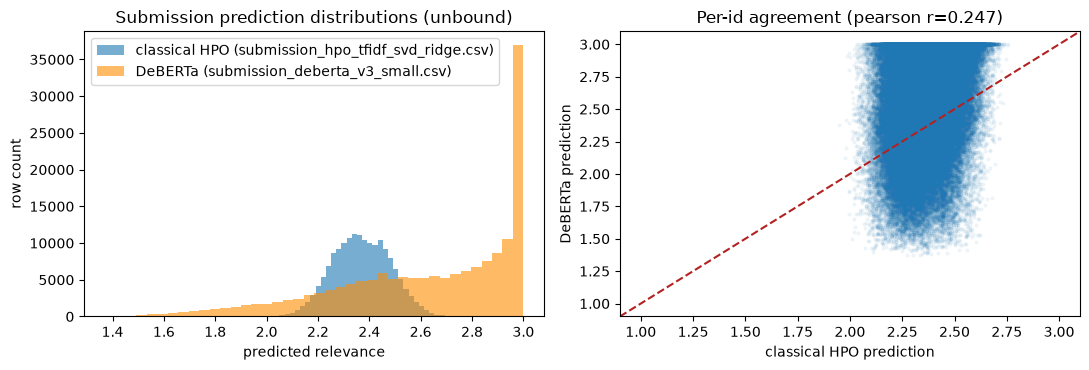

In [10]:
# ruff: noqa: E501
classical_submission_paths = [
    path for path in submission_candidates if "hpo" in path.name.lower()
]
if classical_submission_paths and deberta_paths:
    classical_predictions = pd.read_csv(classical_submission_paths[0])
    deberta_predictions = pd.read_csv(deberta_paths[0])
    merged_predictions = classical_predictions.merge(
        deberta_predictions, on="id", suffixes=("_classical", "_deberta")
    )
    prediction_correlation = merged_predictions["relevance_classical"].corr(
        merged_predictions["relevance_deberta"]
    )
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    axes[0].hist(
        merged_predictions["relevance_classical"],
        bins=40,
        alpha=0.6,
        color="#1F77B4",
        label=f"classical HPO ({classical_submission_paths[0].name})",
    )
    axes[0].hist(
        merged_predictions["relevance_deberta"],
        bins=40,
        alpha=0.6,
        color="#FF8C00",
        label=f"DeBERTa ({deberta_paths[0].name})",
    )
    axes[0].set_xlabel("predicted relevance")
    axes[0].set_ylabel("row count")
    axes[0].set_title("Submission prediction distributions (unbound)")
    axes[0].legend()
    axes[1].scatter(
        merged_predictions["relevance_classical"],
        merged_predictions["relevance_deberta"],
        s=4,
        alpha=0.05,
        color="#1F77B4",
    )
    axes[1].axline((1.0, 1.0), (3.0, 3.0), color="firebrick", linestyle="--")
    axes[1].set_xlabel("classical HPO prediction")
    axes[1].set_ylabel("DeBERTa prediction")
    axes[1].set_title(f"Per-id agreement (pearson r={prediction_correlation:.3f})")
    fig.tight_layout()
    plt.show()
else:
    print(
        "needs-new-evidence: classical HPO and DeBERTa submissions are not both "
        "available; distribution comparison plots skipped"
    )

### Classical vs DeBERTa Decision

**Observation:** The diagnostic displays the available DeBERTa-named artifact path(s) and the metric-row count computed from the summary.

**Interpretation:** An unbound submission path and absent persisted metric row cannot support a classical-versus-DeBERTa performance comparison.

**Action:** Persist DeBERTa evaluation metrics and a manifest binding before comparing architectures.

## 5. Regression Residual and Slice Analysis

Use residual evidence only when the selected OOF file is both explicitly chosen and manifest-bound; otherwise display the precise binding diagnostic.

In [11]:
# ruff: noqa: E501
from IPython.display import display as show_binding_table

artifact_diagnostics: list[str] = []


def needs_new_evidence(message: str) -> None:
    diagnostic = f"needs-new-evidence: {message}"
    artifact_diagnostics.append(diagnostic)
    print(diagnostic)


def load_artifact_manifest(path: Path | str | None) -> dict[str, object]:
    if path is None:
        needs_new_evidence("artifact manifest parameter is unset")
        return {}
    manifest_path = Path(path)
    if not manifest_path.is_file():
        needs_new_evidence(
            f"artifact manifest is unavailable: {artifact_project_path(manifest_path)}"
        )
        return {}
    try:
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError):
        needs_new_evidence(
            f"artifact manifest is invalid: {artifact_project_path(manifest_path)}"
        )
        return {}
    if not isinstance(manifest, dict):
        needs_new_evidence("artifact manifest must map filenames to records")
        return {}
    return manifest


artifact_manifest = load_artifact_manifest(artifact_manifest_path)
oof_path = optional_artifacts["oof"]
oof_is_bound_to_selected_experiment = is_selected_artifact_bound(
    oof_artifact_name, oof_path, "oof", artifact_manifest
)
fold_is_bound_to_selected_experiment = is_selected_artifact_bound(
    fold_artifact_name, optional_artifacts["folds"], "folds", artifact_manifest
)
artifact_binding_diagnostics = pd.DataFrame(
    [
        {
            "kind": "oof",
            "available_path": artifact_project_path(oof_path),
            "bound_to_selected_experiment": oof_is_bound_to_selected_experiment,
            "missing_provenance_condition": "; ".join(artifact_diagnostics) or "none",
            "required_action": "select and bind the OOF artifact before residual analysis",
        },
        {
            "kind": "folds",
            "available_path": artifact_project_path(optional_artifacts["folds"]),
            "bound_to_selected_experiment": fold_is_bound_to_selected_experiment,
            "missing_provenance_condition": "; ".join(artifact_diagnostics) or "none",
            "required_action": "select and bind the fold artifact before validation claims",
        },
    ]
)
if oof_is_bound_to_selected_experiment and oof_path is not None:
    oof = pd.read_csv(oof_path).rename(columns={"relevance": "y_true", "prediction": "y_pred"})
    if not {"y_true", "y_pred"}.issubset(oof.columns):
        raise ValueError("OOF artifact requires y_true/y_pred or relevance/prediction columns.")
    oof = oof.assign(residual=oof["y_true"] - oof["y_pred"])
    artifact_binding_diagnostics = pd.concat(
        [
            artifact_binding_diagnostics,
            oof[["y_true", "y_pred", "residual"]].describe().reset_index(),
        ],
        ignore_index=True,
        sort=False,
    )
show_binding_table(artifact_binding_diagnostics)

,kind,available_path,bound_to_selected_experiment,missing_provenance_condition,required_action,index,y_true,y_pred,residual
0,oof,results/tfidf_svd_all_text_ridge_oof.csv,True,none,select and bind the OOF artifact before residu...,NaN,NaN,NaN,NaN
1,folds,results/tfidf_svd_all_text_ridge_folds.csv,True,none,select and bind the fold artifact before valid...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,count,74067.000000,74067.000000,74067.000000
3,NaN,NaN,NaN,NaN,NaN,mean,2.381634,2.381580,0.000054
4,NaN,NaN,NaN,NaN,NaN,std,0.533984,0.122175,0.522003
5,NaN,NaN,NaN,NaN,NaN,min,1.000000,1.890355,-1.748916
6,NaN,NaN,NaN,NaN,NaN,25%,2.000000,2.294008,-0.341317
7,NaN,NaN,NaN,NaN,NaN,50%,2.330000,2.382158,0.062795
8,NaN,NaN,NaN,NaN,NaN,75%,3.000000,2.469206,0.435581
9,NaN,NaN,NaN,NaN,NaN,max,3.000000,2.826003,1.038439


Visualize residual structure for a manifest-bound OOF artifact: predicted vs
actual density, the residual distribution, per-label residual spread, and
per-label mean prediction (calibration). While the OOF selection is unbound,
the binding diagnostic above remains the only residual evidence.

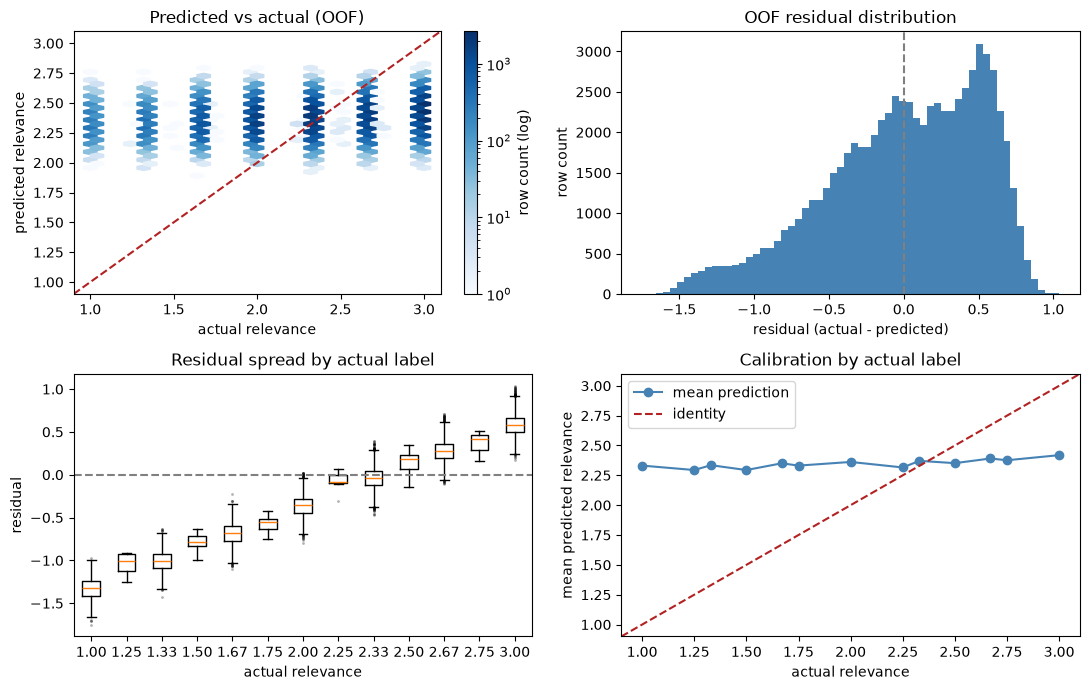

In [12]:
# ruff: noqa: E501
if oof_is_bound_to_selected_experiment and oof_path is not None:
    label_values = sorted(oof["y_true"].unique())
    residuals_by_label = [
        oof.loc[oof["y_true"].eq(label), "residual"].to_numpy()
        for label in label_values
    ]
    mean_prediction_by_label = oof.groupby("y_true")["y_pred"].mean().loc[label_values]
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    density = axes[0, 0].hexbin(
        oof["y_true"], oof["y_pred"], gridsize=25, bins="log", mincnt=1, cmap="Blues"
    )
    axes[0, 0].axline((1.0, 1.0), (3.0, 3.0), color="firebrick", linestyle="--")
    axes[0, 0].set_xlabel("actual relevance")
    axes[0, 0].set_ylabel("predicted relevance")
    axes[0, 0].set_title("Predicted vs actual (OOF)")
    fig.colorbar(density, ax=axes[0, 0], label="row count (log)")
    axes[0, 1].hist(oof["residual"], bins=60, color="steelblue")
    axes[0, 1].axvline(0.0, color="gray", linestyle="--")
    axes[0, 1].set_xlabel("residual (actual - predicted)")
    axes[0, 1].set_ylabel("row count")
    axes[0, 1].set_title("OOF residual distribution")
    axes[1, 0].boxplot(
        residuals_by_label,
        tick_labels=[f"{label:.2f}" for label in label_values],
        flierprops={"marker": ".", "markersize": 2, "alpha": 0.3},
    )
    axes[1, 0].axhline(0.0, color="gray", linestyle="--")
    axes[1, 0].set_xlabel("actual relevance")
    axes[1, 0].set_ylabel("residual")
    axes[1, 0].set_title("Residual spread by actual label")
    axes[1, 1].plot(
        label_values,
        mean_prediction_by_label,
        marker="o",
        color="steelblue",
        label="mean prediction",
    )
    axes[1, 1].axline(
        (1.0, 1.0), (3.0, 3.0), color="firebrick", linestyle="--", label="identity"
    )
    axes[1, 1].set_xlabel("actual relevance")
    axes[1, 1].set_ylabel("mean predicted relevance")
    axes[1, 1].set_title("Calibration by actual label")
    axes[1, 1].legend()
    fig.tight_layout()
    plt.show()
else:
    print(
        "needs-new-evidence: residual plots require a selected, manifest-bound "
        "OOF artifact"
    )

### Residual Analysis Binding Decision

**Observation:** The displayed binding diagnostic names the selected OOF and fold paths, their binding state, and every missing provenance condition collected during evaluation.

**Interpretation:** Residual statistics appear only for a selected, manifest-bound OOF artifact; otherwise the displayed diagnostic is the available evidence.

**Action:** Bind a selected OOF filename to the displayed selected experiment, then rerun residual and slice analysis.

## 6. Failure Review

Require a manifest-bound OOF-derived failure artifact before assigning failure categories; otherwise expose the artifact and binding gap.

In [13]:
# ruff: noqa: E501
failure_review_diagnostic = pd.DataFrame(
    [
        {
            "available_path": project_path(path),
            "missing_provenance_condition": (
                "selected OOF is not manifest-bound"
                if not oof_is_bound_to_selected_experiment
                else "no persisted failure taxonomy artifact is present"
            ),
            "required_action": "persist a manifest-bound OOF-derived failure review",
        }
        for path in oof_candidates
    ]
    or [
        {
            "available_path": None,
            "missing_provenance_condition": "no OOF artifact is available",
            "required_action": "persist and bind OOF-derived failure evidence",
        }
    ]
)
display_table(failure_review_diagnostic)

,available_path,missing_provenance_condition,required_action
0,logs/runs/baseline-mean_baseline-mean_42_oof.csv,no persisted failure taxonomy artifact is present,persist a manifest-bound OOF-derived failure r...
1,logs/runs/baseline-mean_baseline-median_42_oof...,no persisted failure taxonomy artifact is present,persist a manifest-bound OOF-derived failure r...
2,logs/runs/baseline-mean_ridge_42_oof.csv,no persisted failure taxonomy artifact is present,persist a manifest-bound OOF-derived failure r...
3,logs/runs/text-overlap-v2_ridge_42_oof.csv,no persisted failure taxonomy artifact is present,persist a manifest-bound OOF-derived failure r...
4,logs/runs/tfidf-svd-product-title_baseline-mea...,no persisted failure taxonomy artifact is present,persist a manifest-bound OOF-derived failure r...
5,logs/runs/tfidf-svd-product-title_baseline-med...,no persisted failure taxonomy artifact is present,persist a manifest-bound OOF-derived failure r...
6,logs/runs/tfidf-svd-product-title_ridge_42_oof...,no persisted failure taxonomy artifact is present,persist a manifest-bound OOF-derived failure r...
7,logs/runs/tfidf-svd-search-term_baseline-mean_...,no persisted failure taxonomy artifact is present,persist a manifest-bound OOF-derived failure r...
8,logs/runs/tfidf-svd-search-term_baseline-media...,no persisted failure taxonomy artifact is present,persist a manifest-bound OOF-derived failure r...
9,logs/runs/tfidf-svd-search-term_ridge_42_oof.csv,no persisted failure taxonomy artifact is present,persist a manifest-bound OOF-derived failure r...


Visualize failure magnitude for a manifest-bound OOF artifact: the absolute
residual distribution with review thresholds, and severe-case counts per
actual label. While the OOF selection is unbound, the binding gap above
stands and no failure categories are assigned.

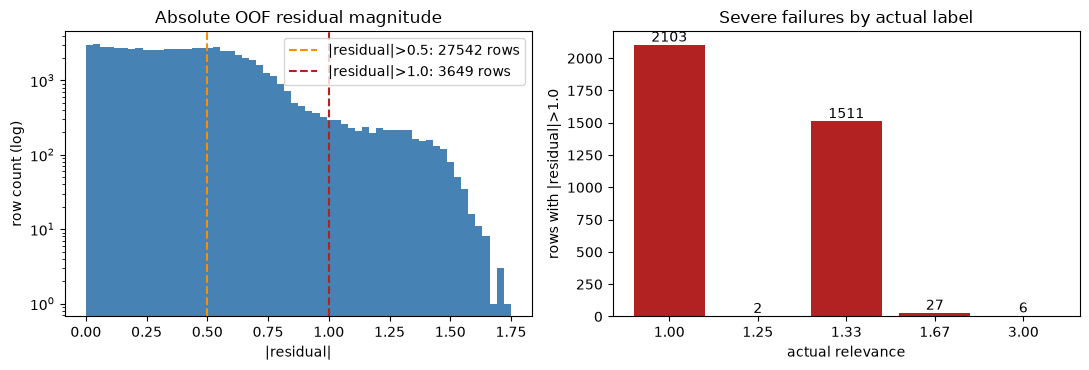

In [14]:
# ruff: noqa: E501
if oof_is_bound_to_selected_experiment and oof_path is not None:
    absolute_residuals = oof["residual"].abs()
    severe_threshold = 1.0
    severe_by_label = (
        oof.loc[absolute_residuals.gt(severe_threshold)]
        .groupby("y_true")["residual"]
        .size()
    )
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    axes[0].hist(absolute_residuals, bins=60, color="steelblue", log=True)
    for threshold, color in ((0.5, "darkorange"), (severe_threshold, "firebrick")):
        exceeding = int(absolute_residuals.gt(threshold).sum())
        axes[0].axvline(
            threshold,
            color=color,
            linestyle="--",
            label=f"|residual|>{threshold}: {exceeding} rows",
        )
    axes[0].set_xlabel("|residual|")
    axes[0].set_ylabel("row count (log)")
    axes[0].set_title("Absolute OOF residual magnitude")
    axes[0].legend()
    bars = axes[1].bar(
        [f"{label:.2f}" for label in severe_by_label.index],
        severe_by_label.to_numpy(),
        color="firebrick",
    )
    axes[1].bar_label(bars, fmt="%d")
    axes[1].set_xlabel("actual relevance")
    axes[1].set_ylabel(f"rows with |residual|>{severe_threshold}")
    axes[1].set_title("Severe failures by actual label")
    fig.tight_layout()
    plt.show()
else:
    print(
        "needs-new-evidence: failure plots require a selected, manifest-bound "
        "OOF artifact"
    )

### Failure Review Decision

**Observation:** The failure-review diagnostic lists the available OOF path(s) and whether the selected OOF binding permits failure evidence.

**Interpretation:** Without a bound OOF-derived failure artifact, assigning categories would exceed the displayed provenance.

**Action:** Persist a failure taxonomy derived from a manifest-bound OOF artifact before recording failure conclusions.

## 7. Submission Sanity Checks

Validate schema and value ranges only for an explicitly selected, manifest-bound submission; otherwise display the submission binding diagnostic.

In [15]:
# ruff: noqa: E501
from IPython.display import display as show_submission_table

submission_path = optional_artifacts.get("submission")
submission_is_bound_to_selected_experiment = is_selected_artifact_bound(
    submission_artifact_name, submission_path, "submission", artifact_manifest
)
if submission_is_bound_to_selected_experiment and submission_path is not None:
    persisted_submission = pd.read_csv(submission_path)
    expected_submission_columns = ["id", "relevance"]
    if list(persisted_submission.columns) != expected_submission_columns:
        raise ValueError(
            "Submission must contain exactly these columns in order: "
            f"{expected_submission_columns}; found {list(persisted_submission.columns)}"
        )
    submission_ids = persisted_submission["id"]
    relevance_values = persisted_submission["relevance"]
    for column, values in (("id", submission_ids), ("relevance", relevance_values)):
        if not bool(values.notna().all()):
            raise ValueError(f"Submission {column} must not contain null values.")
        if not pd.api.types.is_numeric_dtype(values):
            raise ValueError(f"Submission {column} must be numeric.")
        if bool(values.isin((float("inf"), float("-inf"))).any()):
            raise ValueError(f"Submission {column} must contain only finite values.")
    if submission_ids.duplicated().any():
        raise ValueError("Submission id values must be unique.")
    if not relevance_values.between(1.0, 3.0).all():
        raise ValueError("Submission relevance values must be in [1.0, 3.0].")
    submission_checks = pd.DataFrame(
        {
            "available_path": [artifact_project_path(submission_path)],
            "rows": [len(persisted_submission)],
            "columns": [list(persisted_submission.columns)],
            "id_min": [submission_ids.min()],
            "id_max": [submission_ids.max()],
            "relevance_min": [relevance_values.min()],
            "relevance_max": [relevance_values.max()],
            "missing_provenance_condition": ["none"],
            "required_action": ["retain the manifest binding with the submission"],
        }
    )
    show_submission_table(submission_checks)
else:
    submission_diagnostic = pd.DataFrame(
        [
            {
                "available_path": artifact_project_path(submission_path),
                "missing_provenance_condition": "; ".join(artifact_diagnostics) or "submission is unbound",
                "required_action": "select and manifest-bind a submission before schema checks",
            }
        ]
    )
    show_submission_table(submission_diagnostic)

needs-new-evidence: artifact manifest experiment mismatch for submission_hpo_tfidf_svd_ridge.csv


,available_path,missing_provenance_condition,required_action
0,results/submission_hpo_tfidf_svd_ridge.csv,needs-new-evidence: artifact manifest experime...,select and manifest-bind a submission before s...


Visualize the bound submission's predicted-relevance distribution against the
[1.0, 3.0] contract bounds; the bound OOF prediction distribution is overlaid
when available to expose train-to-test prediction shift. Skipped while the
submission selection is unbound.

In [16]:
# ruff: noqa: E501
if submission_is_bound_to_selected_experiment and submission_path is not None:
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.hist(
        persisted_submission["relevance"],
        bins=60,
        density=True,
        alpha=0.6,
        color="#1F77B4",
        label="submission predictions (test)",
    )
    if oof_is_bound_to_selected_experiment and oof_path is not None:
        ax.hist(
            oof["y_pred"],
            bins=60,
            density=True,
            alpha=0.6,
            color="#FF8C00",
            label="OOF predictions (train)",
        )
    for bound in (1.0, 3.0):
        ax.axvline(bound, color="firebrick", linestyle="--")
    ax.set_xlabel("predicted relevance")
    ax.set_ylabel("density")
    ax.set_title("Submission prediction distribution vs contract bounds")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print(
        "needs-new-evidence: submission distribution plot requires a selected, "
        "manifest-bound submission"
    )

needs-new-evidence: submission distribution plot requires a selected, manifest-bound submission


### Submission Sanity Decision

**Observation:** The displayed submission table either contains computed schema and range values for a bound submission or the exact missing binding condition.

**Interpretation:** Submission sanity checks are candidate evidence only when their displayed path is explicitly selected and manifest-bound.

**Action:** Bind a displayed submission filename to the selected experiment before using its schema checks in the decision.

## 8. Final Candidate Decision

Derive the decision from the displayed ranking and artifact-binding statuses rather than assigning a fixed notebook value.

In [17]:
# ruff: noqa: E501
decision_inputs = pd.DataFrame(
    [
        {
            "requirement": "recorded ranking selects the candidate",
            "status": bool(selected_experiment == str(ranked_experiments.loc[0, "experiment"])),
            "evidence_path": project_path(experiment_summary_path),
            "required_action_if_false": "resolve the selected experiment against the ranking",
        },
        {
            "requirement": "selected fold artifact is manifest-bound",
            "status": fold_is_bound_to_selected_experiment,
            "evidence_path": project_path(optional_artifacts["folds"]),
            "required_action_if_false": "select and bind a fold artifact",
        },
        {
            "requirement": "selected OOF artifact is manifest-bound",
            "status": oof_is_bound_to_selected_experiment,
            "evidence_path": project_path(oof_path),
            "required_action_if_false": "select and bind an OOF artifact",
        },
        {
            "requirement": "selected submission is manifest-bound and valid",
            "status": submission_is_bound_to_selected_experiment,
            "evidence_path": project_path(submission_path),
            "required_action_if_false": "select, bind, and validate a submission",
        },
    ]
)
decision = "submit" if bool(decision_inputs["status"].all()) else "needs-new-evidence"
decision_status = decision_inputs.assign(decision=decision)
display_table(decision_status)

,requirement,status,evidence_path,required_action_if_false,decision
0,recorded ranking selects the candidate,False,results/experiment_summary.csv,resolve the selected experiment against the ra...,needs-new-evidence
1,selected fold artifact is manifest-bound,True,results/tfidf_svd_all_text_ridge_folds.csv,select and bind a fold artifact,needs-new-evidence
2,selected OOF artifact is manifest-bound,True,results/tfidf_svd_all_text_ridge_oof.csv,select and bind an OOF artifact,needs-new-evidence
3,selected submission is manifest-bound and valid,False,results/submission_hpo_tfidf_svd_ridge.csv,"select, bind, and validate a submission",needs-new-evidence


### Final Candidate Decision Record

**Observation:** The decision input/status table displays every required condition, its computed status, the supporting path, and the derived decision.

**Interpretation:** The decision changes only when all displayed evidence conditions are satisfied; missing provenance keeps the result evidence-limited.

**Action:** Complete each displayed required action, rerun the notebook, and use the regenerated status table as the decision record.